In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
df = sns.load_dataset("titanic")

print(df.head())
print("\n")
df.info()
print("\n")
print(df.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-

/tmp/ipykernel_2475/846087260.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="survived", data=df, palette=["#ff6b6b", "#6bcb77"])


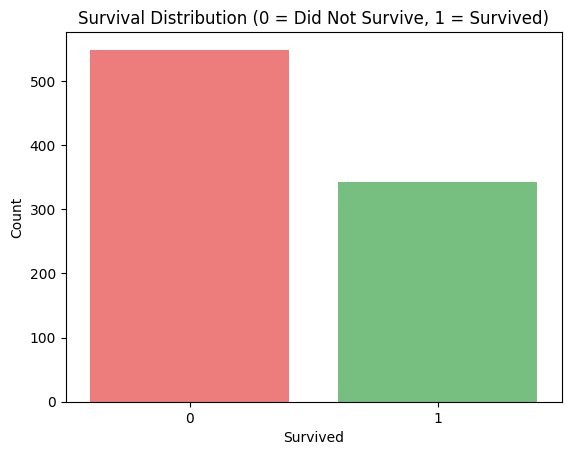

In [3]:
sns.countplot(x="survived", data=df, palette=["#ff6b6b", "#6bcb77"])
plt.title("Survival Distribution (0 = Did Not Survive, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [4]:
# Drop irrelevant columns
df = df.drop(columns=["deck", "embark_town", "alive", "who", "adult_male", "alone"])

# Fill missing numerical values with median
df["age"]  = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

# Fill missing categorical values with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Label encode binary column 'sex' (male/female → 1/0)
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

# OneHot encode 'embarked' (3 unordered categories → k-1 rule)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

# Drop 'class' column — already represented numerically by 'pclass'
df = df.drop(columns=["class"])

print("Shape after cleaning:", df.shape)
print("\nRemaining columns:", list(df.columns))
print("\nMissing values:\n", df.isnull().sum())

Shape after cleaning: (891, 9)

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']

Missing values:
 survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked_Q    0
embarked_S    0
dtype: int64


In [5]:
# Select relevant features as X, target variable as y
X = df.drop(columns=["survived"])
y = df["survived"]

print("Features (X):", list(X.columns))
print("Target (y)  :", y.name)
print("X shape     :", X.shape)
print("y shape     :", y.shape)

Features (X): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']
Target (y)  : survived
X shape     : (891, 8)
y shape     : (891,)


In [6]:
# Split first, then scale (avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler: scales data to mean=0, std=1
# fit_transform on train only, transform on test only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")
print("\nFirst 3 rows of scaled training data:")
print(X_train_scaled.head(3))

Training samples : 712
Testing  samples : 179

First 3 rows of scaled training data:
     pclass      sex       age     sibsp     parch      fare  embarked_Q  \
0 -1.614136  0.72431  1.253641 -0.470722 -0.479342 -0.078684   -0.303355   
1 -0.400551  0.72431 -0.477284 -0.470722 -0.479342 -0.377145   -0.303355   
2  0.813034  0.72431  0.215086 -0.470722 -0.479342 -0.474867   -0.303355   

   embarked_S  
0    0.592489  
1    0.592489  
2    0.592489  


In [7]:
# Train Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

print("Model trained successfully!")
print(f"\nFirst 10 predictions : {y_pred[:10]}")
print(f"First 10 actual      : {y_test.values[:10]}")

Model trained successfully!

First 10 predictions : [0 0 0 1 1 1 1 0 1 1]
First 10 actual      : [1 0 0 1 1 1 1 0 1 1]


Accuracy: 81.01%


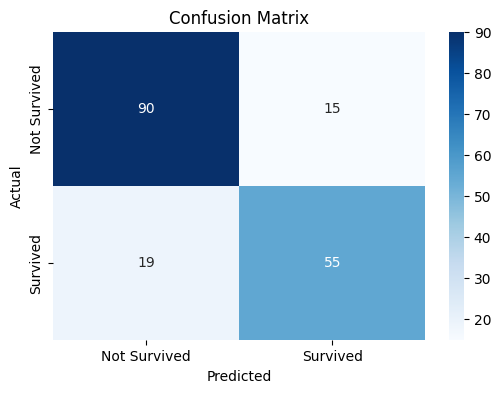


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [8]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

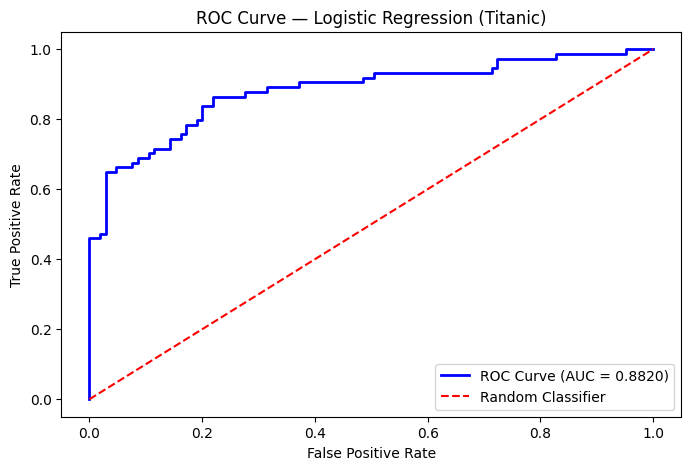

AUC Score: 0.8820


In [9]:
# Get predicted probabilities for ROC curve
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Classifier")
plt.title("ROC Curve — Logistic Regression (Titanic)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

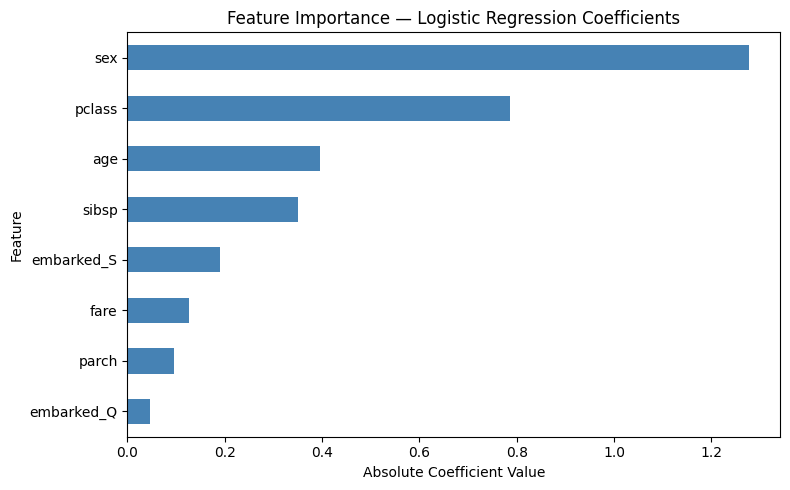

In [10]:
# Get coefficients (importance) of each feature
feature_importance = pd.Series(
    np.abs(model.coef_[0]),   # absolute values to show magnitude
    index=X.columns
).sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Logistic Regression Coefficients")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()